# Basketball Player Segmentation Experiment

This notebook experiments with segmenting basketball players from the DeepSportRadar dataset.

## 1. Set Up the Development Environment

Install necessary packages and import libraries.

In [7]:
!pip install opencv-python torch torchvision pycocotools matplotlib numpy


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import cv2
import os
import json
import numpy as np
import matplotlib.pyplot as plt

## 2. Define Initial Functions

Utility functions for loading and inspecting the DeepSportRadar dataset.

In [9]:
def load_annotation_json(path):
    with open(path, 'r') as f:
        return json.load(f)


def display_image(img, title='Image'):
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


# just use for initial quick inspect
def get_sample_paths(data_dir):
    # Example: items are grouped by arena/game_id folder
    for arena in os.listdir(data_dir):
        arena_path = os.path.join(data_dir, arena)
        if os.path.isdir(arena_path) and arena.startswith('KS-FR'):
            for game_id in os.listdir(arena_path):
                game_path = os.path.join(arena_path, game_id)
                if os.path.isdir(game_path):
                    for fname in os.listdir(game_path):
                        if fname.endswith('_0.png'):
                            yield os.path.join(game_path, fname), os.path.join(game_path, fname.replace('_0.png', '_humans.png'))


## 3. Implement Basic Logic

Implement basic dataset class, model and training loop.

In [10]:
class BasketballDatasetTorch(Dataset):
    def __init__(self, data_dir, transform=None):
        self.files = []
        self.transform = transform
        for img_path, mask_path in get_sample_paths(data_dir):
            if os.path.exists(mask_path):
                self.files.append((img_path, mask_path))
        
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path, mask_path = self.files[idx]
        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.transform:
            img = self.transform(img)
            mask = self.transform(mask)

        # transform mask to binary
        mask = (mask > 128).float()

        return img, mask

class SimpleSegModel(nn.Module):
    def __init__(self):
        super(SimpleSegModel, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


def train_segmentation_model(data_dir, epochs=5, batch_size=4):
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])

    dataset = BasketballDatasetTorch(data_dir, transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = SimpleSegModel()
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        epoch_loss = 0.0
        for imgs, masks in dataloader:
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks.unsqueeze(1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss / len(dataloader):.4f}")

    torch.save(model.state_dict(), '/Users/aryanchadha/NBAPlayerTracker/models/segmentation_model.pth')
    return model


## 4. Test the Implementation

Run the model training on a small subset and visualize sample outputs.

Found 728 sample image/mask pairs


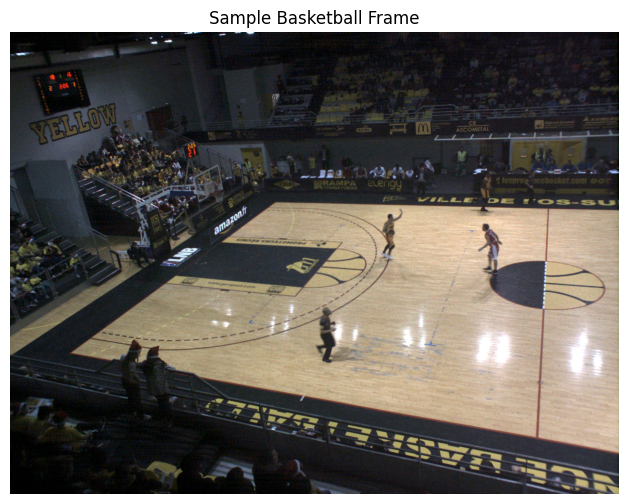

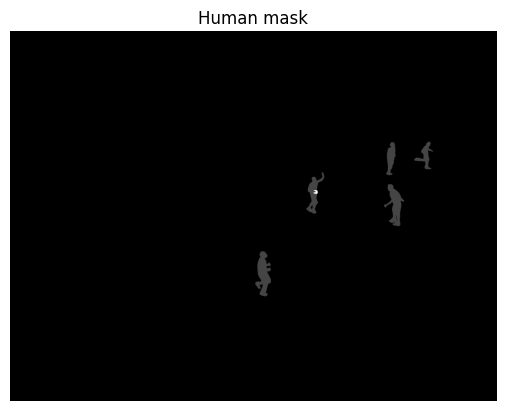

ValueError: Using a target size (torch.Size([2, 1, 1, 256, 256])) that is different to the input size (torch.Size([2, 1, 256, 256])) is deprecated. Please ensure they have the same size.

In [ ]:
# Quick dataset sanity check
sample_paths = list(get_sample_paths('/Users/aryanchadha/NBAPlayerTracker/data'))
print(f"Found {len(sample_paths)} sample image/mask pairs")

if len(sample_paths) > 0:
    img_path, mask_path = sample_paths[0]
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    display_image(img, 'Sample Basketball Frame')
    plt.imshow(mask, cmap='gray')
    plt.title('Human mask')
    plt.axis('off')
    plt.show()

# Train model for a quick test
#model = train_segmentation_model('/Users/aryanchadha/NBAPlayerTracker/data', epochs=2, batch_size=2)
# (uncomment to run - may take some time depending on macOS GPU/CPU speed)


## 5. Add mIoU evaluation and training readiness

Add evaluation logic to measure segmentation quality and prepare the notebook for more exhaustive training in Colab.

In [12]:
def compute_iou(pred, target, threshold=0.5, eps=1e-6):
    pred_bin = (pred > threshold).float()
    target_bin = (target > 0.5).float()
    intersection = (pred_bin * target_bin).sum()
    union = pred_bin.sum() + target_bin.sum() - intersection
    return (intersection + eps) / (union + eps)


# Verify the manifest exists and count valid pairs
manifest_path = '/Users/aryanchadha/NBAPlayerTracker/data/dataset_manifest.csv'
with open(manifest_path, 'r') as f:
    sample_count = sum(1 for _ in f) - 1
print(f'Found {sample_count} image/mask pairs in the manifest')


# Example of using the new training script locally
print('Run the segmentation training script for a baseline:')
print('python3 scripts/train_segmentation.py')


# Suggested next step for Colab
print('For more exhaustive training in Colab, install ultralytics and use the YOLOv8 pipeline next.')


Found 324 image/mask pairs in the manifest
Run the segmentation training script for a baseline:
python3 scripts/train_segmentation.py
For more exhaustive training in Colab, install ultralytics and use the YOLOv8 pipeline next.


## 6. YOLOv8 Player Detection

Switch to detection with YOLOv8 for bounding boxes, preparing for tracking.

In [13]:
!pip install ultralytics scikit-learn

  Using cached pyyaml-6.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 4.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 6.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 24.6/40.8 MB 7.6 MB/s eta 0:00:03^C


In [ ]:
# Convert segmentation masks to YOLO bounding boxes
!python scripts/convert_masks_to_boxes.py

In [ ]:
# Train YOLOv8 model (run in Colab for GPU)
!python scripts/train_yolov8.py

In [ ]:
# Test inference (after training)
!python scripts/infer_yolov8.py